In [216]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math, copy
import decimal
import copy
from lab_utils_multi import zscore_normalize_features

In [217]:
np.set_printoptions(precision=2)


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

i:\Apps\Anaconda Big\envs\excalibur\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\uvang\.cache\kagglehub\datasets\yasserh\housing-prices-dataset\versions\1


In [218]:
df = pd.read_csv("datasets/house_prices.csv")

In [6]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [226]:
y_train = np.array(df["price"], dtype=np.float64)
x_train = np.array(df)
x_features = ["size", "bedrooms", "bathrooms", "stories"]


In [227]:
x_train=np.array(x_train[:, [1,2,3,4]], dtype=np.float64)
X_norm = zscore_normalize_features(x_train)

In [228]:
X_norm

array([[ 1.05,  1.4 ,  1.42,  1.38],
       [ 1.76,  1.4 ,  5.41,  2.53],
       [ 2.22,  0.05,  1.42,  0.22],
       ...,
       [-0.71, -1.31, -0.57, -0.93],
       [-1.03,  0.05, -0.57, -0.93],
       [-0.6 ,  0.05, -0.57,  0.22]])

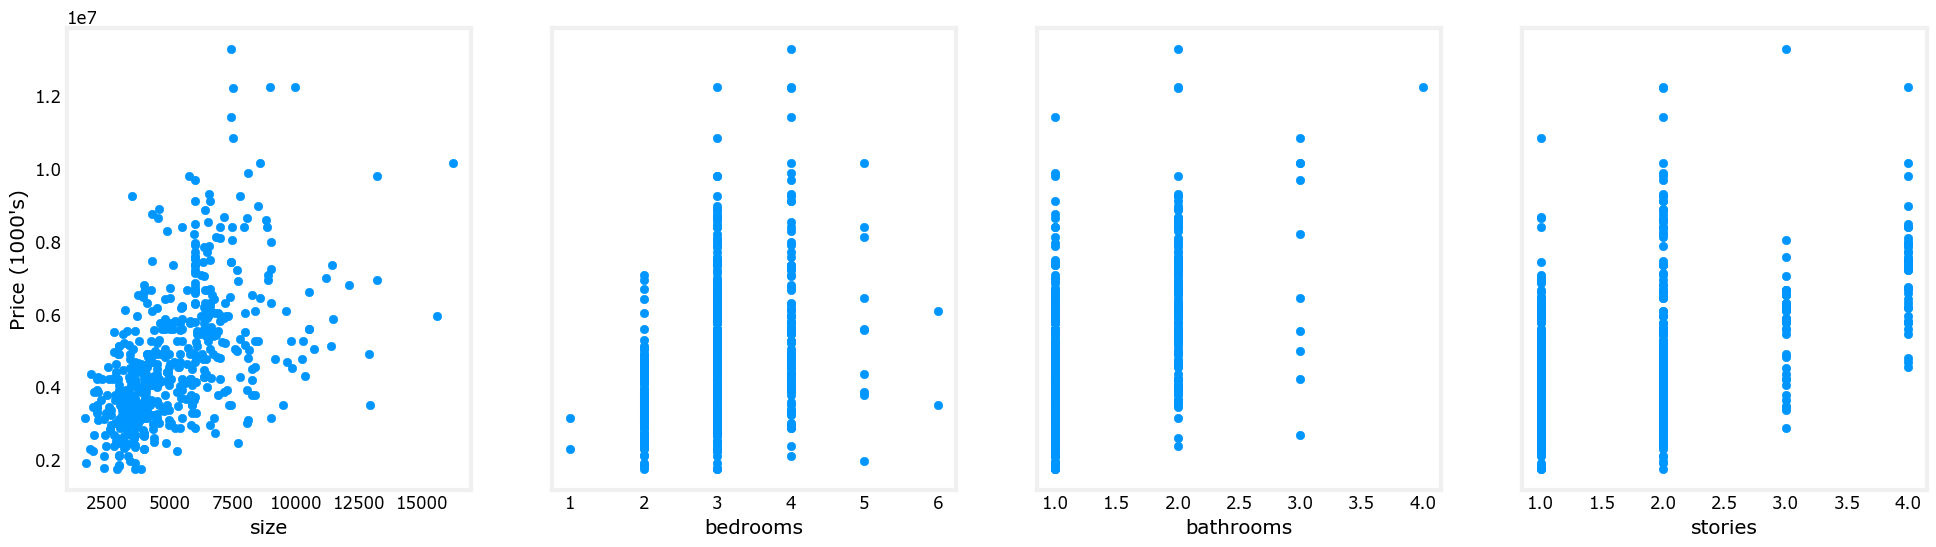

In [229]:
fig,ax=plt.subplots(1, 4, figsize=(24, 6), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train)
    ax[i].set_xlabel(x_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

In [90]:
def compute_cost(x, y, w,b ):
    m = x.shape[0]
    final_cost = 0
    cost = 0
    for i in range(m):
        cost += (np.dot(x[i], w) + b - y[i]) **2
    
    final_cost = cost/(2 * m)

    return final_cost

In [91]:
def compute_gradient(x,y,w,b):
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err  = (np.dot(x[i],w)+b - y[i])
        for j in range(n):
            dj_dw[j] += err * x[i,j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

    


    




In [92]:
def gradient_descent(x,y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    j_hist = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            j_hist.append(cost_function(x,y,w,b))
        if i % math.ceil(num_iters/10) == 0:
            print(f"Iteration {i}: Cost{j_hist[-1]:e}")
    return w,b, j_hist

In [239]:
w = np.zeros((4,))
b = 0
alpha = 9.5e-10
iterations = 10000

w_fin, b_fin, hist = gradient_descent(X_norm, y_train, w,b, compute_cost,compute_gradient, alpha, iterations)


Iteration 0: Cost1.310692e+13
Iteration 1000: Cost1.310689e+13
Iteration 2000: Cost1.310687e+13
Iteration 3000: Cost1.310684e+13
Iteration 4000: Cost1.310682e+13


KeyboardInterrupt: 

In [208]:
w_fin

array([nan, nan, nan, nan])

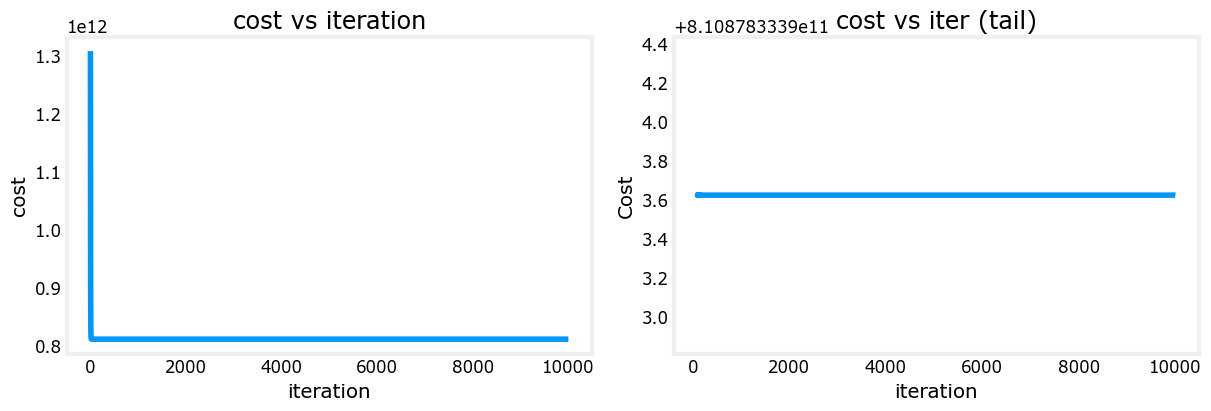

In [237]:
fig, (ax1, ax2) = plt.subplots(1,2, constrained_layout = True, figsize=(12,4))

ax1.plot(hist)
ax2.plot(100+np.arange(len(hist[100:])), hist[100:])
ax1.set_title("cost vs iteration"); ax2.set_title("cost vs iter (tail)")
ax1.set_ylabel("cost"); ax2.set_ylabel("Cost")
ax1.set_xlabel("iteration"); ax2.set_xlabel("iteration")
plt.show()

In [161]:
b_fin

np.float64(1.4334412169905675)

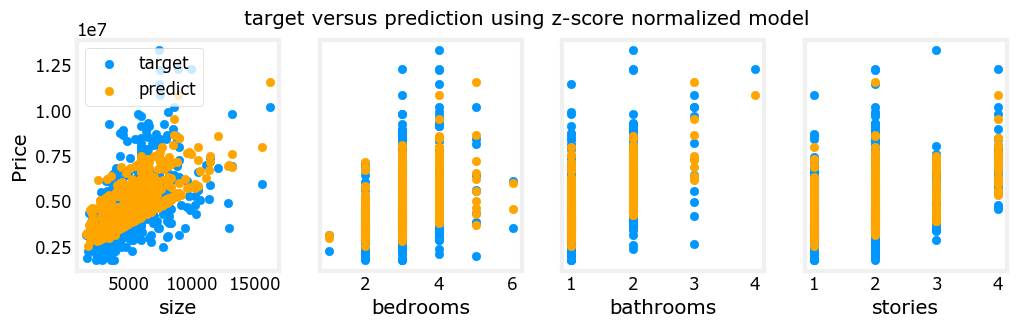

In [238]:
#predict target using normalized features
m = X_norm.shape[0]
yp = np.zeros(m)
for i in range(m):
    yp[i] = (np.dot(X_norm[i], w_fin) + b_fin)

    # plot predictions and targets versus original features    
fig,ax=plt.subplots(1,4,figsize=(12, 3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(x_features[i])
    ax[i].scatter(x_train[:,i],yp,color="orange",label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

In [195]:
x_train

array([[7.42e+03, 4.00e+00, 2.00e+00, 3.00e+00],
       [8.96e+03, 4.00e+00, 4.00e+00, 4.00e+00],
       [9.96e+03, 3.00e+00, 2.00e+00, 2.00e+00],
       ...,
       [3.62e+03, 2.00e+00, 1.00e+00, 1.00e+00],
       [2.91e+03, 3.00e+00, 1.00e+00, 1.00e+00],
       [3.85e+03, 3.00e+00, 1.00e+00, 2.00e+00]])

In [ ]:
x_train[i]
yp[i]

np.float64(0.21269180182615294)

In [ ]:
yp[10]

np.float64(0.21269174517574305)

In [ ]:
x_train[10]

array([1.00e+00, 2.27e-04, 7.58e-05, 1.52e-04])

In [ ]:
x_train[11]

array([1.00e+00, 6.67e-04, 5.00e-04, 3.33e-04])

In [ ]:
yp[11]

np.float64(0.21269179378401173)